In [21]:
import numpy
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Sequential

# from keras.layers import Dense
import tensorflow as tf
import cv2
import os

In [9]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 7700193365949697247
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 1390585038
locality {
  bus_id: 1
  links {
  }
}
incarnation: 7318491773742801627
physical_device_desc: "device: 0, name: NVIDIA GeForce MX150, pci bus id: 0000:01:00.0, compute capability: 6.1"
xla_global_id: 416903419
]


In [4]:
tf.__version__

'2.10.1'

Without Slicing Image

In [10]:
wd='Cleaned ECG'
File_Names=os.listdir(wd)
imagees_org=[]
imagees_clean=[]

for File_Name in File_Names:
    # for Original Images as X for training

    img=cv2.imread('Data/Cropped Reports/'+File_Name,0)
    offset=img.shape[0]-199
    if offset // 2 ==0:
        up_off=down_off=offset/2
    else:
        up_off=int(offset/2)
        down_off=offset-up_off
    if offset==0:
        cropped_image_orginal=img
    else:
        cropped_image_orginal=img[int(up_off):-int(down_off),:]

    imagees_org.append(cropped_image_orginal)

    # for Cleaned Images as Y for training

    img = cv2.imread('Cleaned ECG/'+File_Name,0)
    offset=img.shape[0]-199
    if offset // 2 ==0:
        up_off=down_off=offset/2
    else:
        up_off=int(offset/2)
        down_off=offset-up_off
    if offset==0:
        cropped_image_clean=img
    else:
        cropped_image_clean=img[int(up_off):-int(down_off),:]

    imagees_clean.append(cropped_image_clean)


images_org=np.stack(imagees_org,axis=0)
images_clean=np.stack(imagees_clean,axis=0)


With Slicing Image

In [37]:
cut_off=100
wd='Cleaned ECG'
File_Names=os.listdir(wd)
imagees_org=[]
imagees_clean=[]

for File_Name in File_Names:
    # for Original Images as X for training

    img=cv2.imread('Data/Cropped Reports/'+File_Name,0)
    offset=img.shape[0]-196
    if offset // 2 ==0:
        up_off=down_off=offset/2
    else:
        up_off=int(offset/2)
        down_off=offset-up_off
    if offset==0:
        cropped_image_orginal=img
    else:
        cropped_image_orginal=img[int(up_off):-int(down_off),:]

    imagees_org.append(cropped_image_orginal[:,:cut_off])

    # for Cleaned Images as Y for training

    img = cv2.imread('Cleaned ECG/'+File_Name,0)
    offset=img.shape[0]-196
    if offset // 2 ==0:
        up_off=down_off=offset/2
    else:
        up_off=int(offset/2)
        down_off=offset-up_off
    if offset==0:
        cropped_image_clean=img
    else:
        cropped_image_clean=img[int(up_off):-int(down_off),:]

    imagees_clean.append(cropped_image_clean[:,:cut_off])


images_org=np.stack(imagees_org,axis=0)
images_clean=np.stack(imagees_clean,axis=0)


In [38]:
images_org=images_org.reshape(len(images_org),196,100,1)
images_clean=images_clean.reshape(len(images_org),196,100,1)

In [40]:
images_org.shape

(189, 196, 100, 1)

For Image Check

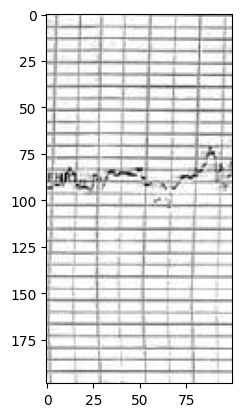

In [12]:
index=85
plt.imshow(images_org[index],cmap='gray')
plt.show()


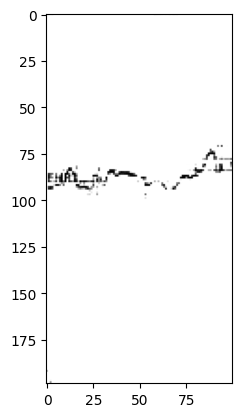

In [13]:
plt.imshow(images_clean[index],cmap='gray')
plt.show()

In [17]:
num_pixels = images_org.shape[1] * images_org.shape[2]
X_train = images_org.reshape(images_org.shape[0], num_pixels).astype('float32')

y_train=images_clean.reshape(images_clean.shape[0], num_pixels).astype('float32')

X_train = X_train / 255
y_train=y_train/255

# create model
# model = Sequential()
# model.add(Dense(18000, input_dim=num_pixels, activation='relu'))
# model.add(Dense(10000, activation='relu'))
# model.add(Dense(1600, activation='relu'))
# model.add(Dense(10000, activation='relu'))
# model.add(Dense(18000, activation='relu'))
# model.add(Dense(num_pixels, activation='sigmoid'))

In [28]:

from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

11490434/11490434 [==============================] - 3s 0us/step


In [29]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
model.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
model.fit(X_train, y_train, validation_data=(X_train, y_train), epochs=1, batch_size=30)

In [51]:
img_T=model.predict(images_org)

6/6 [==============================] - 0s 80ms/step


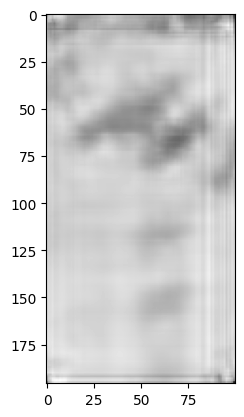

In [52]:
Response=img_T[1]*255

Response=Response.reshape(196,100,1)

plt.imshow(ims,cmap='gray')

In [ ]:
Response=img_T[2]*255

Response=Response.reshape(199,100)

plt.imshow(Response,cmap='gray')

New Model

In [53]:
model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(196, 100, 1)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (5, 5), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (5, 5), activation='relu', padding='same'))
 

model.add(MaxPooling2D((2, 2), padding='same'))
 
model.add(Conv2D(8, (5, 5), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(8, (5, 5), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (5, 5), activation='relu'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(1, (5, 5), activation='relu', padding='same'))

In [54]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [55]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_14 (Conv2D)          (None, 196, 100, 32)      832       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 98, 50, 32)       0         
 2D)                                                             
                                                                 
 conv2d_15 (Conv2D)          (None, 98, 50, 8)         6408      
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 49, 25, 8)        0         
 2D)                                                             
                                                                 
 conv2d_16 (Conv2D)          (None, 49, 25, 8)         1608      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 25, 13, 8)       

In [35]:
images_clean.shape

(189, 199, 100, 1)

In [56]:
model.fit(images_org, images_clean, epochs=40, batch_size=30, shuffle=True, 
          validation_data=(images_org, images_clean))

Epoch 1/40


ValueError: in user code:

    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 994, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\training.py", line 1052, in compute_loss
        return self.compiled_loss(
    File "C:\ProgramData\anaconda3\envs\tf-Test\lib\site-packages\keras\engine\compile_utils.py", line 265, in 